**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-Inspired Machine Learning

Project 1: Hebbian Learning

#### Week 1: TensorFlow, Datasets, and Custom Neural Network Library

In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=4)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2

2026-02-10 15:02:32.251149: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-10 15:02:33.315566: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Task 4. Train `LinearDecoder` on MNIST and CIFAR-10

Woohoo! Your linear decoder is built and tested! Time for some fun! 😎

To train in a reasonable amount of time, upload your project code to CoCalc so that you can train on the GPU (*See detailed instructions and demos in lecture*).

*As noted on the website, if you have a higher-end Macbook with a Pro or Max chip and ≥ 16 GB of memory, you could probably run this workload on your computer if you would prefer. This is entirely optional and the cloud will almost certainly be faster than even the fastest Mac. Setting this up would just provide some extra convenience/flexibility. See the [macOS instructions](https://cs.colby.edu/courses/S26/cs443/software.html#tf) for setup.*

Run the cell below to make sure TensorFlow is running on the GPU.

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print('Running on the GPU')
else:
    print('NOT running on the GPU')

Running on the GPU


In [5]:
from image_datasets import get_dataset, train_val_split
from decoder_nets import LinearDecoder

### 4a. Train `LinearDecoder` on MNIST (default acceleration)

This will be a "hello world" test to make sure your `fit` method is working.

Write code in the cell below to load in MNIST


In [6]:
x_train, y_train, x_test, y_test = get_dataset('mnist', verbose=False)
x_train_split, y_train_split, x_val_split, y_val_split = train_val_split(x_train, y_train)

# KEEP ME
print(f'Your training set data have shape {x_train_split.shape} and they should be (54000, 784)')
print(f'Your training set labels have shape {y_train_split.shape} and they should be (54000,)')
print(f'Your val set data have shape {x_val_split.shape} and they should be (6000, 784)')
print(f'Your val set labels have shape {y_val_split.shape} and they should be (6000,)')
print(f'Your test set data have shape {x_test.shape} and they should be (10000, 784)')
print(f'Your test set labels have shape {y_test.shape} and they should be (10000,)')

    8192/11490434 [..............................] - ETA: 0s

 4947968/11490434 [===========>..................] - ETA: 0s

 8396800/11490434 [====================>.........] - ETA: 0s

11490434/11490434 [==============================] - 0s 0us/step


2026-02-10 15:03:11.398085: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20601 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


Your training set data have shape (54000, 784) and they should be (54000, 784)
Your training set labels have shape (54000,) and they should be (54000,)
Your val set data have shape (6000, 784) and they should be (6000, 784)
Your val set labels have shape (6000,) and they should be (6000,)
Your test set data have shape (10000, 784) and they should be (10000, 784)
Your test set labels have shape (10000,) and they should be (10000,)


Train `LinearDecoder` in the cell below on MNIST for `10` epochs and a batch size of `256`! Print out your accuracy on the test set when training is done.

The **entire** process of training and evaluating test accuracy should take no more than 30 seconds (*at most!*). If it is taking longer, seek help.

Your print outs should look something like:

```
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/9, Training loss 0.533, Val loss 0.284, Val acc SURPRISE
Epoch 0 took: 2.0 secs
Epoch 1/9, Training loss 0.322, Val loss 0.257, Val acc SURPRISE
Epoch 1 took: 1.1 secs
Epoch 2/9, Training loss 0.299, Val loss 0.243, Val acc SURPRISE
Epoch 2 took: 1.1 secs
...
Epoch 9/9, Training loss 0.272, Val loss 0.234, Val acc SURPRISE
Epoch 9 took: 1.1 secs
Finished training after 10 epochs!
Linear Decoder MNIST Test accuracy: SURPRISE%
Training took: 12.55 secs
```

The val and test accuracy should be satisfyingly high — in the 90s.

In [7]:
# KEEP THIS SEED
tf.random.set_seed(0)

with tf.device('/GPU:0'):
    
    net = LinearDecoder(C=10, input_feats_shape=(784,))
    net.compile()

    # train the network
    start_time = time.time()
    train_loss_hist, val_loss_hist, val_acc_hist, num_epochs = net.fit(
        x_train_split, y_train_split,
        x_val=x_val_split, y_val=y_val_split,
        batch_size=256,
        max_epochs=10,
        val_every=1,
        print_every=1,
        verbose=True
    )
    total_time = time.time() - start_time

    # evaluating on test set
    test_acc, test_loss = net.evaluate(x_test, y_test)
    print(f'Linear Decoder MNIST Test accuracy: {test_acc.numpy()*100:.1f}%')
    print(f'Training took: {total_time:.2f} secs')


---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------


I0000 00:00:1770735793.492132     658 service.cc:145] XLA service 0x5991ba36df40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770735793.492163     658 service.cc:153]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-02-10 15:03:13.512261: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-10 15:03:13.552831: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90400
I0000 00:00:1770735793.642597     658 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 0/9, Training loss 0.528, Val loss 0.286, Val acc 0.9224
Epoch 0 took: 3.0 secs


Epoch 1/9, Training loss 0.322, Val loss 0.263, Val acc 0.9257
Epoch 1 took: 1.9 secs


Epoch 2/9, Training loss 0.296, Val loss 0.246, Val acc 0.9306
Epoch 2 took: 1.9 secs


...

Epoch 6/9, Training loss 0.268, Val loss 0.231, Val acc 0.9367
Epoch 6 took: 1.8 secs


Epoch 7/9, Training loss 0.268, Val loss 0.228, Val acc 0.9365
Epoch 7 took: 1.8 secs


Epoch 8/9, Training loss 0.263, Val loss 0.231, Val acc 0.9336
Epoch 8 took: 1.8 secs


Epoch 9/9, Training loss 0.262, Val loss 0.232, Val acc 0.9362
Epoch 9 took: 1.8 secs
Finished training after 10 epochs!


Linear Decoder MNIST Test accuracy: 92.4%
Training took: 19.40 secs


### 4b. Train `LinearDecoder` on MNIST on the CPU

To appreciate the advantage for training deep networks on GPUs instead of your computer's CPU, copy-paste your code above that trains your `LinearDecoder` net on MNIST below. Instead of running it on CoCalc, run it locally on your computer. Be sure to print out the time per epoch.

*If the net takes >2 minutes per epoch on your computer, just train for one epoch then call it quits :)*

In [8]:
# KEEP THIS SEED
tf.random.set_seed(0)

with tf.device('/CPU:0'):
    
    net = LinearDecoder(C=10, input_feats_shape=(784,))
    net.compile()

    # train the network
    start_time = time.time()
    train_loss_hist, val_loss_hist, val_acc_hist, num_epochs = net.fit(
        x_train_split, y_train_split,
        x_val=x_val_split, y_val=y_val_split,
        batch_size=256,
        max_epochs=10,
        val_every=1,
        print_every=1,
        verbose=True
    )
    total_time = time.time() - start_time

    # evaluating on test set
    test_acc, test_loss = net.evaluate(x_test, y_test)
    print(f'Linear Decoder MNIST Test accuracy: {test_acc.numpy()*100:.1f}%')
    print(f'Training took: {total_time:.2f} secs')


---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------


I0000 00:00:1770735813.087819     658 service.cc:145] XLA service 0x5991bb38cf00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770735813.087845     658 service.cc:153]   StreamExecutor device (0): Host, Default Version


Epoch 0/9, Training loss 0.528, Val loss 0.286, Val acc 0.9224
Epoch 0 took: 2.1 secs


Epoch 1/9, Training loss 0.322, Val loss 0.263, Val acc 0.9257
Epoch 1 took: 1.6 secs


Epoch 2/9, Training loss 0.296, Val loss 0.246, Val acc 0.9308
Epoch 2 took: 1.7 secs


...

Epoch 6/9, Training loss 0.268, Val loss 0.231, Val acc 0.9367
Epoch 6 took: 1.6 secs


Epoch 7/9, Training loss 0.268, Val loss 0.228, Val acc 0.9365
Epoch 7 took: 1.6 secs


Epoch 8/9, Training loss 0.263, Val loss 0.231, Val acc 0.9336
Epoch 8 took: 1.6 secs


Epoch 9/9, Training loss 0.262, Val loss 0.232, Val acc 0.9362
Epoch 9 took: 1.6 secs
Finished training after 10 epochs!


Linear Decoder MNIST Test accuracy: 92.4%
Training took: 16.72 secs


### 4c. Questions

**Question 1:** Approximately how long did it take for 1 epoch of training with and without the GPU. Compute the relative compute time (`gpu_time_per_epoch`/`cpu_time_per_epoch`). What do you think?

**Answer 1:** ANSWER HERE

In [9]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 4d. Train `LinearDecoder` on CIFAR-10

Now let's train on CIFAR-10. Run this (*and all subsequent large training sessions*) on CoCalc/the GPU 😊

Write code in the cell below to load in CIFAR-10 with global RGB normalization.

In [10]:
x_train, y_train, x_test, y_test = get_dataset('cifar10', verbose=False)
x_train_split, y_train_split, x_val_split, y_val_split = train_val_split(x_train, y_train)

# KEEP ME
print(f'Your training set data have shape {x_train_split.shape} and they should be (45000, 3072)')
print(f'Your training set labels have shape {y_train_split.shape} and they should be (45000,)')
print(f'Your val set data have shape {x_val_split.shape} and they should be (5000, 3072)')
print(f'Your val set labels have shape {y_val_split.shape} and they should be (5000,)')
print(f'Your test set data have shape {x_test.shape} and they should be (10000, 3072)')
print(f'Your test set labels have shape {y_test.shape} and they should be (10000,)')

     8192/170498071 [..............................] - ETA: 0s

   204800/170498071 [..............................] - ETA: 56s

  1318912/170498071 [..............................] - ETA: 15s

  4268032/170498071 [..............................] - ETA: 6s 

  9355264/170498071 [>.............................] - ETA: 3s

...

169066496/170498071 [============================>.] - ETA: 0s

169705472/170498071 [============================>.] - ETA: 0s

170295296/170498071 [============================>.] - ETA: 0s

170498071/170498071 [==============================] - 17s 0us/step


Your training set data have shape (45000, 3072) and they should be (45000, 3072)
Your training set labels have shape (45000,) and they should be (45000,)
Your val set data have shape (5000, 3072) and they should be (5000, 3072)
Your val set labels have shape (5000,) and they should be (5000,)
Your test set data have shape (10000, 3072) and they should be (10000, 3072)
Your test set labels have shape (10000,) and they should be (10000,)


Train `LinearDecoder` on CIFAR-10 in the cell below for `10` epochs and use a batch size of `256`.

*You should anticipate no more than ~1 min of total training time on the GPU. If this is far off, please seek help.*

Plot the training and val loss over epochs. Put test acc in the title. *If everything is working, your training and validation loss should steadily decrease then start to plateau by the end of training.*

In [11]:
# KEEP THIS SEED
tf.random.set_seed(0)

# Train LinearDecoder on CIFAR-10
net = LinearDecoder(C=10, input_feats_shape=(3072,))
net.compile()

# train the network
start_time = time.time()
train_loss_hist, val_loss_hist, val_acc_hist, num_epochs = net.fit(
    x_train_split, y_train_split,
    x_val=x_val_split, y_val=y_val_split,
    batch_size=256,
    max_epochs=10,
    val_every=1,
    print_every=1,
    verbose=True
)
total_time = time.time() - start_time

# evaluating on test set
test_acc, test_loss = net.evaluate(x_test, y_test)
print(f'Linear Decoder CIFAR-10 Test accuracy: {test_acc.numpy()*100:.1f}%')
print(f'Training took: {total_time:.2f} secs')


---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------


Epoch 0/9, Training loss 1.850, Val loss 1.851, Val acc 0.3730
Epoch 0 took: 1.7 secs


Epoch 1/9, Training loss 1.777, Val loss 1.878, Val acc 0.3594
Epoch 1 took: 1.5 secs


Epoch 2/9, Training loss 1.739, Val loss 1.832, Val acc 0.3802
Epoch 2 took: 1.5 secs


Epoch 3/9, Training loss 1.740, Val loss 1.848, Val acc 0.3776
Epoch 3 took: 1.5 secs


...

Epoch 6/9, Training loss 1.715, Val loss 1.827, Val acc 0.3790
Epoch 6 took: 1.5 secs


Epoch 7/9, Training loss 1.698, Val loss 1.849, Val acc 0.3806
Epoch 7 took: 1.6 secs


Epoch 8/9, Training loss 1.688, Val loss 1.840, Val acc 0.3712
Epoch 8 took: 1.5 secs


Epoch 9/9, Training loss 1.684, Val loss 1.850, Val acc 0.3762
Epoch 9 took: 1.5 secs
Finished training after 10 epochs!


Linear Decoder CIFAR-10 Test accuracy: 37.1%
Training took: 15.52 secs


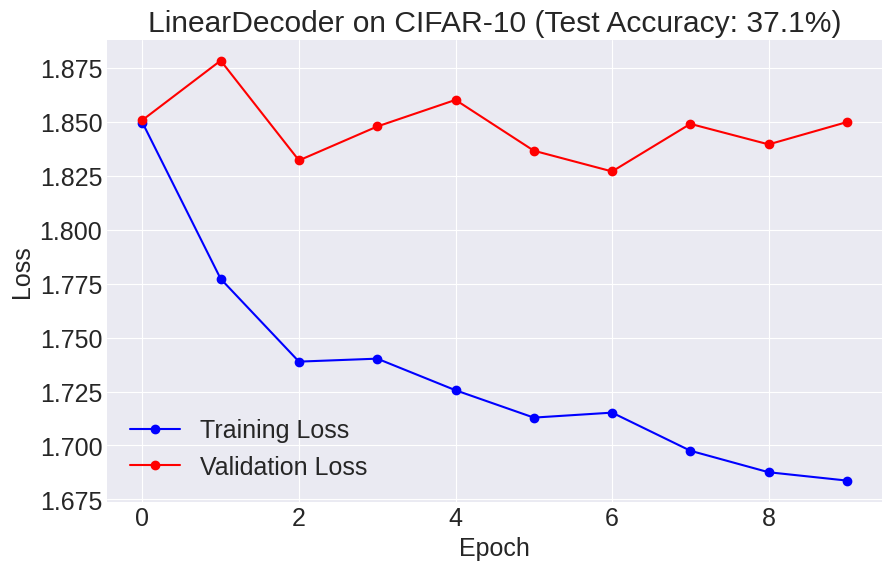

In [12]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
epochs_range = range(num_epochs)
plt.plot(epochs_range, train_loss_hist, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss_hist, 'r-o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'LinearDecoder on CIFAR-10 (Test Accuracy: {test_acc.numpy()*100:.1f}%)')
plt.legend()
plt.grid(True)
plt.show()


### 4e. Experiment: Effect of batch size on runtime and accuracy

To develop your intuition about how the choice of batch size generally affects runtime and accuracy on a dataset like CIFAR-10, run an experiment in which fresh `LinearDecoder` nets are trained for `10` epochs with one of the following batch sizes:<br/>
`[128, 256, 512, 1024, 2048]`. After each training run, record the test accuracy and runtime.

Create two plots:
1. The test accuracy (y axis) as a function of the batch size (x axis). There should be 5 markers joined by a single curve.
2. The runtime (y axis) as a function of the batch size (x axis). There should be 5 markers joined by a single curve.

**Note:**
- Your `fit` method prints the runtime per epoch, but in this task you should record the total runtime over training and prediction. (in seconds). To do this, it may make sense to use the time module to record the total time in the notebook cell below.
- You should be running this on the GPU!

In [13]:
# KEEP THIS SEED
tf.random.set_seed(0)

# testing with different batch sizes
batch_sizes = [128, 256, 512, 1024, 2048]
test_accuracies = []
runtimes = []

for batch_size in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Training with batch size: {batch_size}")
    print(f"{'='*60}")
    
    # creating and compiling the network
    net = LinearDecoder(C=10, input_feats_shape=(3072,))
    net.compile()
    
    # training the network
    start_time = time.time()
    train_loss_hist, val_loss_hist, val_acc_hist, num_epochs = net.fit(
        x_train_split, y_train_split,
        x_val=x_val_split, y_val=y_val_split,
        batch_size=batch_size,
        max_epochs=10,
        val_every=1,
        print_every=10,
        verbose=True
    )
    
    # now we evaluate on the test set
    test_acc, test_loss = net.evaluate(x_test, y_test)
    total_time = time.time() - start_time
    
    test_accuracies.append(test_acc.numpy())
    runtimes.append(total_time)
    
    print(f'Test accuracy: {test_acc.numpy()*100:.1f}%')
    print(f'Total runtime: {total_time:.2f} secs')



Training with batch size: 128
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------


Epoch 0/9, Training loss 1.882, Val loss 1.863, Val acc 0.3730
Epoch 0 took: 3.0 secs


Epoch 1/9, Training loss 1.807, Val loss 1.880, Val acc 0.3662
Epoch 1 took: 2.8 secs


Epoch 2/9, Training loss 1.788, Val loss 1.923, Val acc 0.3592
Epoch 2 took: 2.8 secs


Epoch 3/9, Training loss 1.768, Val loss 1.891, Val acc 0.3662
Epoch 3 took: 2.7 secs


...

Epoch 6/9, Training loss 1.698, Val loss 1.774, Val acc 0.3988
Epoch 6 took: 0.4 secs


Epoch 7/9, Training loss 1.691, Val loss 1.764, Val acc 0.4040
Epoch 7 took: 0.4 secs


Epoch 8/9, Training loss 1.678, Val loss 1.774, Val acc 0.3952
Epoch 8 took: 0.4 secs


Epoch 9/9, Training loss 1.677, Val loss 1.762, Val acc 0.4002
Epoch 9 took: 0.5 secs
Finished training after 10 epochs!


Test accuracy: 39.6%
Total runtime: 5.35 secs


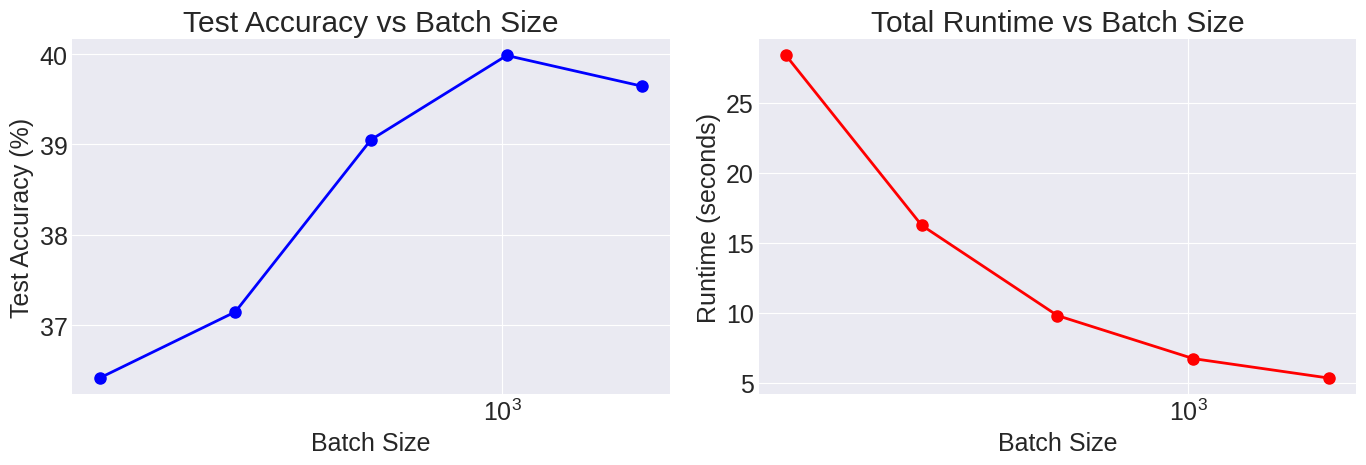

In [14]:
# two plots for accuracy vs batch size and runtime vs batch size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Test accuracy vs batch size
ax1.plot(batch_sizes, [acc*100 for acc in test_accuracies], 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy vs Batch Size')
ax1.grid(True)
ax1.set_xscale('log')

# Runtime vs batch size
ax2.plot(batch_sizes, runtimes, 'r-o', linewidth=2, markersize=8)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Runtime (seconds)')
ax2.set_title('Total Runtime vs Batch Size')
ax2.grid(True)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

### 4f. Questions

**Question 2:** What do the plots suggest to you about the relationship between batch size and accuracy? Please be specific,citing evidence from your plots.

**Question 3:** Do you find this relationship surprising? Why or why not?

**Answer 2:** Based on the Test Accuracy vs Batch Size plot, it reveals a linear relationship between test accuracy and batch size. In other words, as the batch size increases, the test accuracy also increases.

**Answer 3:** This relationship is not surprising because larger batch sizes provide more training examples per gradient update, which would ultimately allow the model to learn more patterns and achieve higher accuracy.